In [1]:
# 加载《时间机器》字符序列数据，为 LSTM 语言模型训练做准备。
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
data = d2l.TimeMachine(batch_size=batch_size, num_steps=num_steps)
train_iter = data.train_dataloader()
vocab = data.vocab


In [2]:
# 初始化 LSTM 的输入门、遗忘门、输出门和候选记忆元参数。
#初始化模型参数
def get_lstm_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device)*0.01


    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xi, W_hi, b_i = three()  # 输入门参数
    W_xf, W_hf, b_f = three()  # 遗忘门参数
    W_xo, W_ho, b_o = three()  # 输出门参数
    W_xc, W_hc, b_c = three()  # 候选记忆元参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, W_xc, W_hc,
              b_c, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params


In [3]:
# LSTM 的状态包含隐藏状态 H 和记忆元 C。
#定义模型
def init_lstm_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),
            torch.zeros((batch_size, num_hiddens), device=device))


In [4]:
# 手写 LSTM 前向传播：门控机制决定记忆保留、写入和输出。
def lstm(inputs, state, params):
    [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, W_xc, W_hc, b_c,
     W_hq, b_q] = params
    (H, C) = state
    outputs = []
    for X in inputs:
        I = torch.sigmoid((X @ W_xi) + (H @ W_hi) + b_i)
        F = torch.sigmoid((X @ W_xf) + (H @ W_hf) + b_f)
        O = torch.sigmoid((X @ W_xo) + (H @ W_ho) + b_o)
        C_tilda = torch.tanh((X @ W_xc) + (H @ W_hc) + b_c)
        C = F * C + I * C_tilda
        H = O * torch.tanh(C)
        Y = (H @ W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H, C)


In [14]:
# 补充训练和预测所需的从零实现模型封装与训练函数。
import math
import torch
from torch import nn
from torch.nn import functional as F
import d2l.torch as d2l

# ============ 补充新版缺失的 RNNModelScratch ============
class RNNModelScratch:
    """从零实现的 RNN 模型（兼容 LSTM 等变体）"""
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params, init_state, forward_fn):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state, forward_fn

    def __call__(self, X, state):
        # X: (batch_size, num_steps) → one-hot → (num_steps, batch_size, vocab_size)
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)

# ============ 补充新版缺失的 train_ch8 ============
def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    """训练模型（抄自教材第8章）"""
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])

    # 初始化 updater
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params, lr, batch_size)

    def predict(prefix):
        return predict_ch8(prefix, 50, net, vocab, device)

    for epoch in range(num_epochs):
        # --- 一个 epoch 的训练 ---
        state, timer = None, d2l.Timer()
        metric = d2l.Accumulator(2)  # 损失之和, 词元数
        for X, Y in train_iter:
            if state is None or use_random_iter:
                state = net.begin_state(batch_size=X.shape[0], device=device)
            else:
                if isinstance(net, nn.Module):
                    state = None
                else:
                    if state[0].shape[0] != X.shape[0]:         # ← 加这两行
                        state = net.begin_state(batch_size=X.shape[0], device=device)
                    else:
                        for s in state:
                            s.detach_()
            y = Y.T.reshape(-1)
            X, y = X.to(device), y.to(device)
            y_hat, state = net(X, state)
            l = loss(y_hat, y.long()).mean()
            if isinstance(updater, torch.optim.Optimizer):
                updater.zero_grad()
                l.backward()
                d2l.grad_clipping(net, 1)
                updater.step()
            else:
                l.backward()
                d2l.grad_clipping(net, 1)
                updater(batch_size=1)
            metric.add(l * y.numel(), y.numel())
        # --- 输出 ---
        if (epoch + 1) % 10 == 0:
            ppl = math.exp(metric[0] / metric[1])
            animator.add(epoch + 1, [ppl])
    ppl = math.exp(metric[0] / metric[1])
    print(f'perplexity {ppl:.1f}, {metric[1] / timer.stop():.1f} tokens/sec on {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))

# ============ 补充 predict_ch8 ============
def predict_ch8(prefix, num_preds, net, vocab, device):
    """在 prefix 后面生成 num_preds 个字符"""
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape(1, 1)
    # 预热期：用 prefix 更新状态
    for y in prefix[1:]:
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    # 预测期
    for _ in range(num_preds):
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])


perplexity 1.5, 9833.1 tokens/sec on cuda:0
time traveller but now you begin to see the object of my investi
traveller smiled are you sure we can move freely in space r


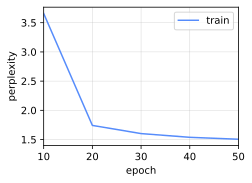

In [16]:
# 使用从零实现的 LSTM 进行训练和文本预测。
#训练和预测

vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 50, 1
model = RNNModelScratch(len(vocab), num_hiddens, device, get_lstm_params,init_lstm_state, lstm)
train_ch8(model, train_iter, vocab, lr, num_epochs, device)


time traveller t te t te t te t te t te t te t te t te t te t te
traveller t te t te t te t te t te t te t te t te t te t te


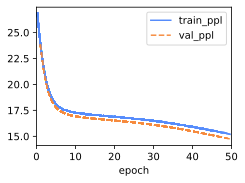

In [1]:
# 使用 PyTorch 内置 nn.LSTM 简洁实现同样的语言模型。
#简洁的实现
import d2l.torch as d2l
from torch import nn

# 数据
data = d2l.TimeMachine(batch_size=32, num_steps=35)
vocab = data.vocab

# 模型
num_inputs = len(vocab)
num_hiddens = 256
lstm_layer = nn.LSTM(num_inputs, num_hiddens)
model = d2l.RNNLM(lstm_layer, len(vocab))

# 训练
device = d2l.try_gpu()
model.to(device)
trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1,num_gpus=1)
trainer.fit(model, data)

# 预测
print(model.predict('time traveller', 50, vocab=vocab, device=device))
print(model.predict('traveller', 50, vocab=vocab, device=device))
